In [2]:
!pip install torch

  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
    --------------------------------------- 2.9/123.0 MB 20.1 MB/s eta 0:00:06
   -- ------------------------------------- 6.3/123.0 MB 18.6 MB/s eta 0:00:07
   --- ------------------------------------ 10.5/123.0 MB 21.7 MB/s eta 0:00:06
   ---- ----------------------------------- 12.6/123.0 MB 16.6 MB/s eta 0:00:07
   ---- ----------------------------------- 13.9/123.0 MB 14.6 MB/s eta 0:00:08
   ---- ----------------------------------- 14.9/123.0 MB 12.6 MB/s eta 0:00:09
   ----- ---------------------------------- 16.0/123.0 MB 11.4 MB/s eta 0:00:10
   ----- ---------------------------------- 17.0/123.0 MB 10.5 MB/s eta 0:00:11
   ----- ---------------------------------- 18.1/123.0 MB 9.9 MB/s eta 0:00:11
   ------ --------------------------------- 19.1/123.0 MB 9.5 MB/s eta 0:00:11
   -----


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import numpy as np
import joblib

In [5]:
X_train = np.load(
    "../data/processed/X_train.npy"
)

X_test = np.load(
    "../data/processed/X_test.npy"
)

y_train = np.load(
    "../data/processed/y_train.npy"
)

y_test = np.load(
    "../data/processed/y_test.npy"
)

In [6]:
label_encoder = joblib.load(
    "../data/processed/label_encoder.pkl"
)

In [7]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(189, 2151)
(48, 2151)
(189,)
(48,)


In [8]:
import torch

X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long
)

print(X_train_tensor.shape)
print(y_train_tensor.shape)

torch.Size([189, 2151])
torch.Size([189])


In [9]:
X_train_tensor = X_train_tensor.unsqueeze(1)

X_test_tensor = X_test_tensor.unsqueeze(1)

print(X_train_tensor.shape)
print(X_test_tensor.shape)

torch.Size([189, 1, 2151])
torch.Size([48, 1, 2151])


In [10]:
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Test batches :", len(test_loader))

Train batches: 12
Test batches : 3


In [11]:
import torch.nn as nn

class MineralCNN(nn.Module):

    def __init__(self, num_classes=38):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv1d(
                in_channels=1,
                out_channels=16,
                kernel_size=5,
                padding=2
            ),

            nn.ReLU(),

            nn.MaxPool1d(2),

            nn.Conv1d(
                16,
                32,
                kernel_size=5,
                padding=2
            ),

            nn.ReLU(),

            nn.MaxPool1d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                32 * 537,
                256
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                256,
                num_classes
            )
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [12]:
model = MineralCNN(
    num_classes=38
)

print(model)

MineralCNN(
  (features): Sequential(
    (0): Conv1d(1, 16, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=17184, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=38, bias=True)
  )
)


In [13]:
sample_batch = next(
    iter(train_loader)
)

X_batch, y_batch = sample_batch

outputs = model(X_batch)

print(outputs.shape)

torch.Size([16, 38])


In [14]:
print(X_train_tensor.shape)
print(X_test_tensor.shape)

print(len(train_loader))
print(len(test_loader))

print(outputs.shape)

torch.Size([189, 1, 2151])
torch.Size([48, 1, 2151])
12
3
torch.Size([16, 38])


In [15]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Ready")

Ready


In [16]:
num_epochs = 30

train_losses = []

for epoch in range(num_epochs):

    model.train()

    running_loss = 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(
            outputs,
            y_batch
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {epoch_loss:.4f}"
    )

Epoch [1/30] Loss: 3.7542
Epoch [2/30] Loss: 3.3039
Epoch [3/30] Loss: 2.9986
Epoch [4/30] Loss: 2.7564
Epoch [5/30] Loss: 2.5016
Epoch [6/30] Loss: 2.4065
Epoch [7/30] Loss: 2.2180
Epoch [8/30] Loss: 1.8668
Epoch [9/30] Loss: 1.8523
Epoch [10/30] Loss: 1.7472
Epoch [11/30] Loss: 1.6444
Epoch [12/30] Loss: 1.4898
Epoch [13/30] Loss: 1.4842
Epoch [14/30] Loss: 1.2644
Epoch [15/30] Loss: 1.1777
Epoch [16/30] Loss: 1.1833
Epoch [17/30] Loss: 1.2118
Epoch [18/30] Loss: 1.1377
Epoch [19/30] Loss: 1.0221
Epoch [20/30] Loss: 0.9405
Epoch [21/30] Loss: 0.9589
Epoch [22/30] Loss: 0.9819
Epoch [23/30] Loss: 0.8738
Epoch [24/30] Loss: 0.7923
Epoch [25/30] Loss: 0.8048
Epoch [26/30] Loss: 0.6986
Epoch [27/30] Loss: 0.6905
Epoch [28/30] Loss: 0.6441
Epoch [29/30] Loss: 0.7223
Epoch [30/30] Loss: 0.6121


In [17]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        outputs = model(X_batch)

        _, predicted = torch.max(
            outputs,
            1
        )

        total += y_batch.size(0)

        correct += (
            predicted == y_batch
        ).sum().item()

accuracy = 100 * correct / total

print(
    f"Test Accuracy: {accuracy:.2f}%"
)

Test Accuracy: 41.67%


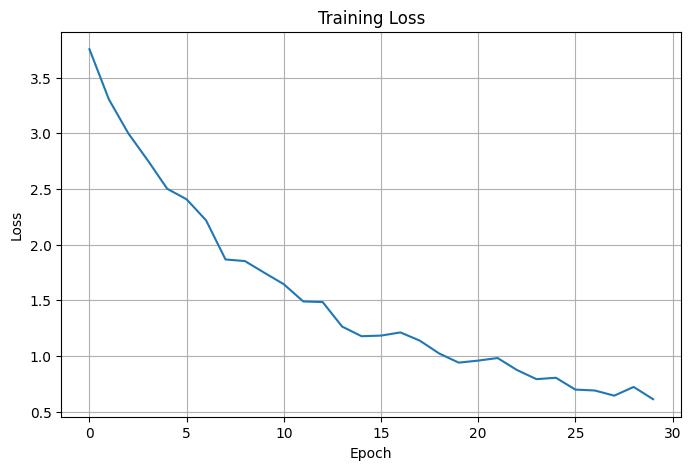

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.grid(True)

plt.show()

In [19]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        outputs = model(X_batch)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.numpy())
        all_labels.extend(y_batch.numpy())

cm = confusion_matrix(
    all_labels,
    all_preds
)

print(cm.shape)

(38, 38)


c:\Users\prewa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
c:\Users\prewa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
c:\Users\prewa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
c:\Users\prewa\AppData\Loca

In [21]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for X_batch, y_batch in train_loader:

        outputs = model(X_batch)

        _, predicted = torch.max(outputs, 1)

        total += y_batch.size(0)

        correct += (predicted == y_batch).sum().item()

train_acc = 100 * correct / total

print("Train Accuracy:", train_acc)

Train Accuracy: 83.06878306878306


In [25]:
import os
from tqdm import tqdm
import pandas as pd
import numpy as np

In [26]:
mineral_path = "../data/raw/usgs/usgs_splib07/ASCIIdata/ASCIIdata_splib07a/ChapterM_Minerals"

In [27]:
files = [
    f for f in os.listdir(mineral_path)
    if f.endswith(".txt")
]

In [28]:
print("Total files:", len(files))
print(files[:5])

Total files: 1276
['splib07a_Acmite_NMNH133746_Pyroxene_BECKa_AREF.txt', 'splib07a_Actinolite_HS116.1B_ASDFRb_AREF.txt', 'splib07a_Actinolite_HS116.2B_ASDFRb_AREF.txt', 'splib07a_Actinolite_HS116.3B_ASDFRb_AREF.txt', 'splib07a_Actinolite_HS116.3B_BECKb_AREF.txt']


In [32]:
length_counts = {}

for file in files:

    file_path = os.path.join(mineral_path, file)

    with open(file_path, "r") as f:

        next(f)

        count = sum(1 for line in f if line.strip())

    length_counts[count] = length_counts.get(count, 0) + 1

print(length_counts)

{480: 439, 2151: 448, 4595: 389}


In [34]:
import os
import pandas as pd
from collections import Counter
from tqdm import tqdm

mineral_path = "../data/raw/usgs/usgs_splib07/ASCIIdata/ASCIIdata_splib07a/ChapterM_Minerals"

files = [
    f for f in os.listdir(mineral_path)
    if f.endswith(".txt")
]

print("Total files:", len(files))

Total files: 1276


In [35]:
metadata = []

for file in files:

    parts = file.replace(".txt", "").split("_")

    mineral = parts[1]

    metadata.append({
        "filename": file,
        "mineral": mineral
    })

metadata_df = pd.DataFrame(metadata)

counts = metadata_df["mineral"].value_counts()

top_29 = counts[counts >= 10]

print(top_29)
print()
print("Total spectra:", top_29.sum())

mineral
Topaz              41
Olivine            41
Muscovite          33
Alunite            30
Jarosite           22
Albite             21
Microcline         20
Kaolinite          20
Hematite           20
Actinolite         19
Clinochlore        18
Chlorite           18
Hypersthene        18
Almandine          17
Montmorillonite    17
Andradite          16
Hornblende         16
Diopside           16
Antigorite         14
Lepidolite         14
Serpentine         13
Goethite           12
Talc               12
Illite             12
Magnetite          12
Phlogopite         12
Grossular          10
Anorthite          10
Monazite           10
Name: count, dtype: int64

Total spectra: 534


In [36]:
dataset = []

for file in tqdm(files):

    parts = file.replace(".txt", "").split("_")

    mineral = parts[1]

    if mineral not in top_29.index:
        continue

    file_path = os.path.join(mineral_path, file)

    reflectance = []

    with open(file_path, "r") as f:

        next(f)

        for line in f:

            line = line.strip()

            if line:
                reflectance.append(float(line))

    if len(reflectance) != 2151:
        continue

    row = {
        "mineral": mineral,
        "filename": file
    }

    for i, value in enumerate(reflectance):
        row[f"band_{i}"] = value

    dataset.append(row)

  0%|          | 0/1276 [00:00<?, ?it/s]

100%|██████████| 1276/1276 [00:01<00:00, 863.05it/s] 


In [37]:
master_df = pd.DataFrame(dataset)

print(master_df.shape)
print()
print("Unique minerals:", master_df["mineral"].nunique())
print()
print(master_df["mineral"].value_counts())

(157, 2153)

Unique minerals: 27

mineral
Albite             13
Actinolite         11
Diopside           10
Serpentine         10
Microcline         10
Hornblende          8
Magnetite           8
Monazite            8
Alunite             7
Olivine             7
Muscovite           7
Topaz               7
Lepidolite          5
Almandine           5
Talc                5
Andradite           5
Chlorite            5
Phlogopite          4
Anorthite           4
Illite              4
Jarosite            3
Kaolinite           3
Antigorite          2
Montmorillonite     2
Clinochlore         2
Goethite            1
Hematite            1
Name: count, dtype: int64


In [38]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(189, 2151)
(48, 2151)
(189,)
(48,)
